In [ ]:
# Install libraries if they are missing
conda install scikit-learn
conda install pandas
conda install matplotlib
conda install numpy 
conda install joblib

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

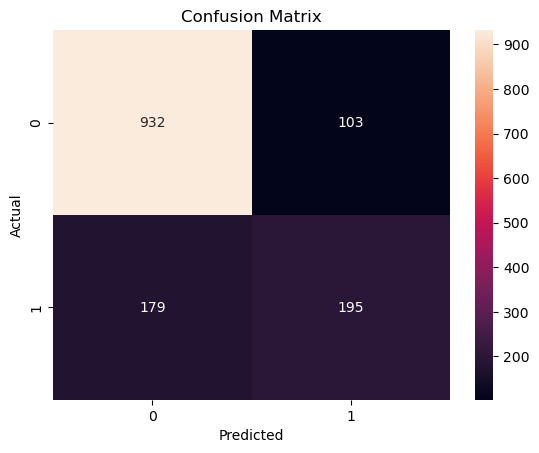

tenure                            0.192361
TotalCharges                      0.156614
MonthlyCharges                    0.117158
InternetService_Fiber optic       0.072997
Contract_Two year                 0.064389
PaymentMethod_Electronic check    0.060803
Contract_One year                 0.034531
OnlineSecurity_Yes                0.033017
TechSupport_Yes                   0.025537
PaperlessBilling_Yes              0.022638
dtype: float64


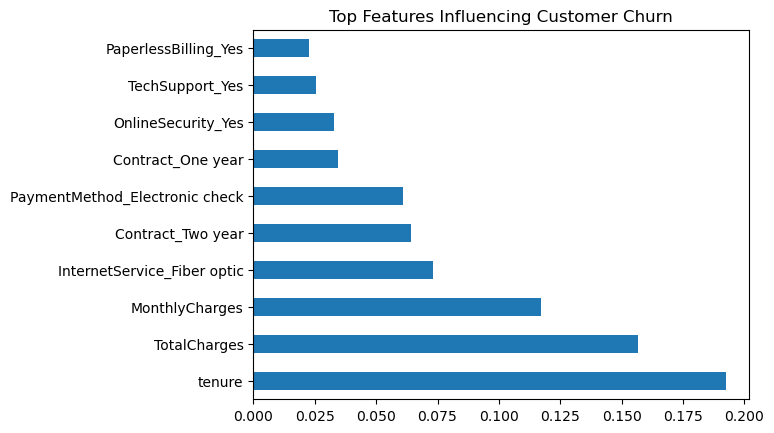

['churn_model.pkl']

In [24]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import joblib

# 2. Load Dataset.
df = pd.read_csv("data/churn.csv")

# 3. Do EDA
df.describe()
df.info()

# Check if any data is missing
df.isna().sum()

# Copy the dataset
df_tmp = df.copy()

# 4. Data Cleaning
# Since there are missing values (blanks) in TotalCharges which makes the variable show as str.
df_tmp["TotalCharges"] = pd.to_numeric(df_tmp["TotalCharges"], errors="coerce") # coerce means: If a value cannot be converted to a number, replace it with NaN instead of throwing an error.

# Convert it to numeric and take median value to fill the blanks.
df_tmp["TotalCharges"] = df_tmp["TotalCharges"].fillna(df_tmp["TotalCharges"].median())

# 5. Feature Engineering
# Create dummy variables for str variables.
df_tmp = pd.get_dummies(df_tmp, columns = ["gender","Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService",
                                      "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                                      "Contract", "PaperlessBilling", "PaymentMethod", "StreamingMovies"], drop_first=True, dtype=int)
df_tmp["Churn"] = pd.get_dummies(df_tmp["Churn"], drop_first=True, dtype=int)

# Create X and y variables
X = df_tmp.drop(["customerID", "Churn"], axis = 1)
y = df_tmp["Churn"]

#Load the CLassification model
model = RandomForestClassifier(n_estimators=300,
                                max_depth=10, 
                                min_samples_split=5,
                                random_state=42)

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Model Training
# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# 8. Model Evaluation
# Check model score
model_score = model.score(X_test, y_test)
print(f"Model score is {model_score:.4f}.")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f}")

# Check classification report
print(classification_report(y_test, y_pred))

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)
print(top_features)

top_features.plot(kind="barh")
plt.title("Top Features Influencing Customer Churn")
plt.show()

# Saving the model
joblib.dump(model, "churn_model.pkl")